<a href="https://colab.research.google.com/github/jadlm3407/AgenticFlow/blob/main/Prediccion_mundiales_1_(gemini).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Celda 1: Importar repositorios y librerías iniciales
!git clone https://github.com/martj42/international_results.git

import pandas as pd

# Cargar los datos principales en DataFrames de Pandas
df_results = pd.read_csv('/content/international_results/results.csv')
df_shootouts = pd.read_csv('/content/international_results/shootouts.csv')
df_goalscorers = pd.read_csv('/content/international_results/goalscorers.csv')

# Visualizar las primeras 5 filas del dataset principal para confirmar que cargó bien
df_results.head()

Cloning into 'international_results'...
remote: Enumerating objects: 1089, done.
remote: Counting objects: 100% (457/457), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 1089 (delta 429), reused 317 (delta 304), pack-reused 632 (from 2)
Receiving objects: 100% (1089/1089), 5.49 MiB | 9.87 MiB/s, done.
Resolving deltas: 100% (646/646), done.


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [ ]:
# Celda 2: Configuración de la predicción y limpieza de datos

# 1. Configuración: Los equipos del partido a predecir
equipo_1 = 'South Africa'
equipo_2 = 'Canada'

# 2. Limpieza y conversión de tipos
# Convertimos la columna 'date' a formato datetime de Pandas para poder operar con años
df_results['date'] = pd.to_datetime(df_results['date'])

# 3. Filtrado: Nos quedamos solo con los partidos desde el año 2018
df_historico = df_results[df_results['date'].dt.year >= 2018].copy()

# Eliminamos posibles valores nulos que puedan dar error al entrenar el modelo
df_historico = df_historico.dropna()

# Reseteamos el índice de la tabla para que sea continuo tras descartar las filas antiguas
df_historico.reset_index(drop=True, inplace=True)

# Comprobamos con cuántos datos nos hemos quedado para entrenar
print(f"Total de partidos disponibles para el modelo (desde 2018): {len(df_historico)}")
display(df_historico.head())

Total de partidos disponibles para el modelo (desde 2018): 8180


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2018-01-02,Iraq,United Arab Emirates,0.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
1,2018-01-02,Oman,Bahrain,1.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
2,2018-01-05,Oman,United Arab Emirates,0.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
3,2018-01-07,Estonia,Sweden,1.0,1.0,Friendly,Abu Dhabi,United Arab Emirates,True
4,2018-01-11,Denmark,Sweden,0.0,1.0,Friendly,Abu Dhabi,United Arab Emirates,True


In [ ]:
# Celda 3: Cálculo de Fuerza Ofensiva y Defensiva (Modelo de Poisson / Dixon-Coles)
import statsmodels.formula.api as smf
import pandas as pd

# 1. Reestructurar los datos: necesitamos una fila por cada equipo por partido
# Extraemos los datos desde la perspectiva del equipo local
df_home = df_historico[['home_team', 'away_team', 'home_score', 'neutral']].copy()
df_home = df_home.rename(columns={'home_team': 'team', 'away_team': 'opponent', 'home_score': 'goals'})
df_home['venue'] = 'home'

# Extraemos los datos desde la perspectiva del equipo visitante
df_away = df_historico[['away_team', 'home_team', 'away_score', 'neutral']].copy()
df_away = df_away.rename(columns={'away_team': 'team', 'home_team': 'opponent', 'away_score': 'goals'})
df_away['venue'] = 'away'

# Combinamos ambos dataframes
df_poisson = pd.concat([df_home, df_away], ignore_index=True)

# Ajustamos la ventaja de campo: si el partido es neutral, lo marcamos
df_poisson.loc[df_poisson['neutral'] == True, 'venue'] = 'neutral'

# 2. Entrenar el modelo
# Le decimos que los 'goles' dependen de quién ataca ('team'), quién defiende ('opponent') y si juegan en casa ('venue')
print("Entrenando el modelo de Poisson (Dixon-Coles)...")
modelo_dixon_coles = smf.poisson(formula="goals ~ team + opponent + venue", data=df_poisson).fit(disp=False)

# 3. Función para extraer las fuerzas ofensivas y defensivas del modelo
def obtener_fuerzas(equipo):
    # Statsmodels usa al primer equipo alfabéticamente como referencia (valor 0).
    # Con `.get()` evitamos errores si el equipo buscado es justo el de referencia o si no existe
    ataque = modelo_dixon_coles.params.get(f'team[T.{equipo}]', 0.0)
    defensa = modelo_dixon_coles.params.get(f'opponent[T.{equipo}]', 0.0)
    return ataque, defensa

# 4. Probamos con los equipos que configuraste en la celda 2
atk_eq1, def_eq1 = obtener_fuerzas(equipo_1)
atk_eq2, def_eq2 = obtener_fuerzas(equipo_2)

print("\n--- Estadísticas estimadas del Modelo ---")
print(f"{equipo_1}: Fuerza Ofensiva = {atk_eq1:.4f} | Vulnerabilidad Defensiva = {def_eq1:.4f}")
print(f"{equipo_2}: Fuerza Ofensiva = {atk_eq2:.4f} | Vulnerabilidad Defensiva = {def_eq2:.4f}")
print("\n* NOTA: En Fuerza Ofensiva, cuanto más alto (positivo), más goles anota.")
print("* NOTA: En Vulnerabilidad Defensiva, cuanto más bajo (negativo), menos goles recibe.")

Entrenando el modelo de Poisson (Dixon-Coles)...

--- Estadísticas estimadas del Modelo ---
South Africa: Fuerza Ofensiva = 1.5364 | Vulnerabilidad Defensiva = -1.2175
Canada: Fuerza Ofensiva = 1.9207 | Vulnerabilidad Defensiva = -1.3938

* NOTA: En Fuerza Ofensiva, cuanto más alto (positivo), más goles anota.
* NOTA: En Vulnerabilidad Defensiva, cuanto más bajo (negativo), menos goles recibe.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Preparando datos y entrenando modelo XGBoost...

--- Goles Esperados (xG) por XGBoost ---
South Africa: 0.86 xG
Canada: 0.68 xG


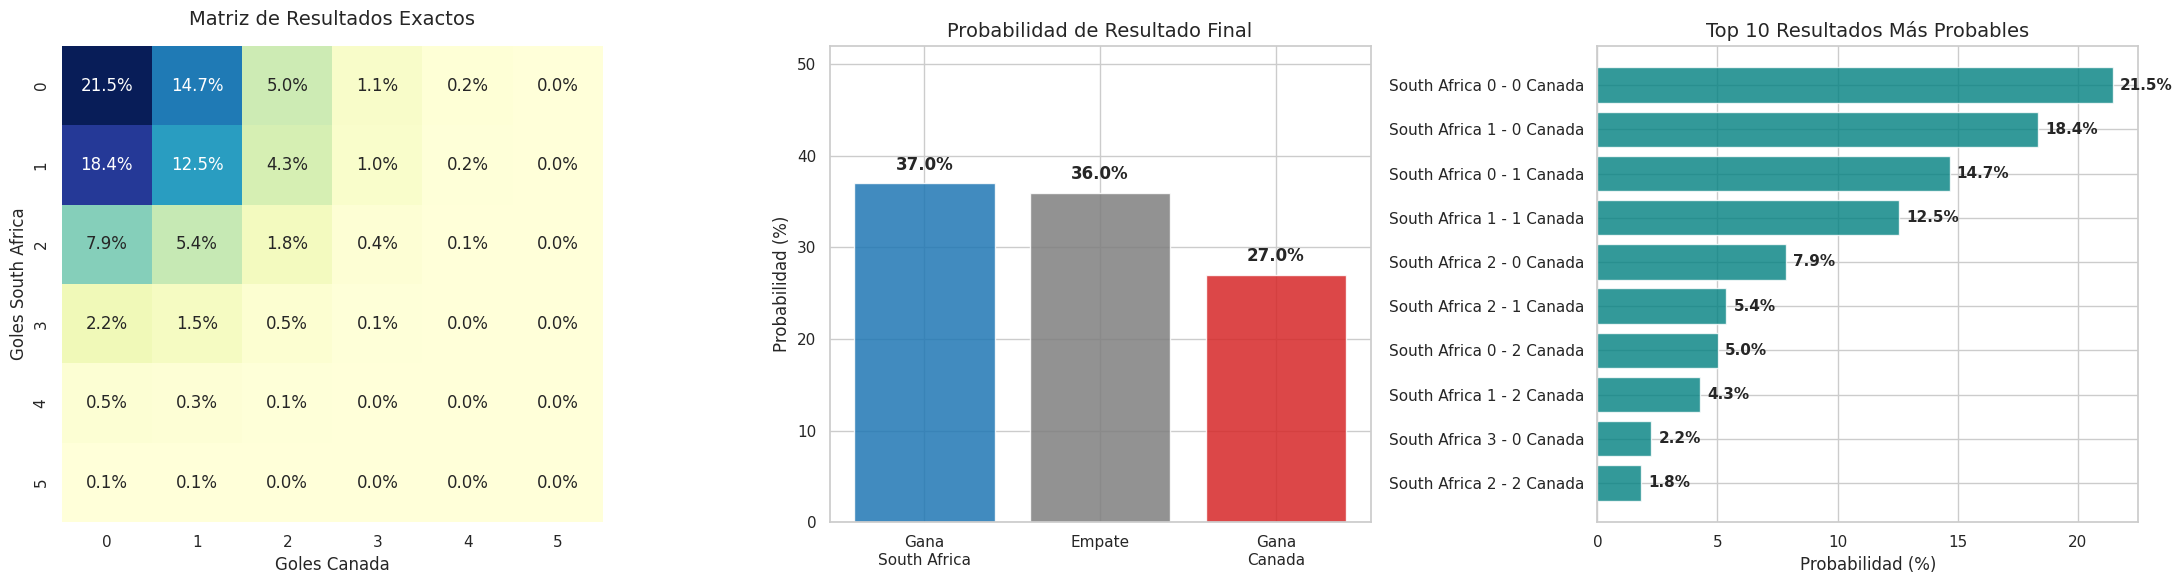


--- Precisión del Modelo XGBoost ---
Error Absoluto Medio (MAE): 0.955 goles de desviación promedio.


In [ ]:
# Celda 4: Modelo XGBoost, Simulación Monte Carlo y Matriz de Probabilidades (Gráficas Actualizadas)
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

print("Preparando datos y entrenando modelo XGBoost...")

# 1. PREPARACIÓN DE DATOS PARA XGBOOST
df_xgb = df_poisson.copy()

df_xgb['team'] = df_xgb['team'].astype('category')
df_xgb['opponent'] = df_xgb['opponent'].astype('category')
df_xgb['venue'] = df_xgb['venue'].astype('category')

X = df_xgb[['team', 'opponent', 'venue']]
y = df_xgb['goals']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. ENTRENAMIENTO DEL MODELO XGBOOST
xgb_model = xgb.XGBRegressor(
    objective='count:poisson',
    tree_method='hist',
    enable_categorical=True,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 3. PREDICCIÓN DE GOLES ESPERADOS (xG) PARA NUESTRO PARTIDO
match_data = pd.DataFrame({
    'team': [equipo_1, equipo_2],
    'opponent': [equipo_2, equipo_1],
    'venue': ['neutral', 'neutral']
})
match_data['team'] = match_data['team'].astype(X_train['team'].dtypes)
match_data['opponent'] = match_data['opponent'].astype(X_train['opponent'].dtypes)
match_data['venue'] = match_data['venue'].astype(X_train['venue'].dtypes)

xG_pred = xgb_model.predict(match_data)
xG_eq1, xG_eq2 = xG_pred[0], xG_pred[1]

print(f"\n--- Goles Esperados (xG) por XGBoost ---")
print(f"{equipo_1}: {xG_eq1:.2f} xG")
print(f"{equipo_2}: {xG_eq2:.2f} xG")

# 4. MATRIZ DE PROBABILIDAD DE POISSON
max_goles = 6 # Calcularemos hasta 5 goles
goles_rango = np.arange(0, max_goles)

prob_goles_eq1 = poisson.pmf(goles_rango, xG_eq1)
prob_goles_eq2 = poisson.pmf(goles_rango, xG_eq2)
matriz_probabilidades = np.outer(prob_goles_eq1, prob_goles_eq2)

# 5. EXTRACCIÓN DE DATOS PARA LAS NUEVAS GRÁFICAS
# Extraemos victoria, empate y derrota usando operaciones de matrices (numpy)
prob_empate = np.trace(matriz_probabilidades) * 100
prob_victoria_eq1 = np.tril(matriz_probabilidades, -1).sum() * 100
prob_victoria_eq2 = np.triu(matriz_probabilidades, 1).sum() * 100

outcomes = [f'Gana\n{equipo_1}', 'Empate', f'Gana\n{equipo_2}']
probs_outcomes = [prob_victoria_eq1, prob_empate, prob_victoria_eq2]

# Calculamos el Top 10 de resultados exactos aplanando la matriz
flat_probs = matriz_probabilidades.flatten()
top_10_idx = np.argsort(flat_probs)[-10:][::-1] # Obtenemos los 10 índices con mayor %

top_10_scores = []
top_10_probs = []

for idx in top_10_idx:
    g1 = idx // max_goles # Calculamos los goles del equipo 1
    g2 = idx % max_goles  # Calculamos los goles del equipo 2
    top_10_scores.append(f'{equipo_1} {g1} - {g2} {equipo_2}')
    top_10_probs.append(flat_probs[idx] * 100)

# Invertimos el orden para que en el gráfico la barra más alta salga arriba del todo
top_10_scores.reverse()
top_10_probs.reverse()

# 6. VISUALIZACIÓN EN 3 PANELES ACTUALIZADA
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: Matriz de Probabilidades (Heatmap)
sns.heatmap(matriz_probabilidades, annot=True, fmt=".1%", cmap="YlGnBu", ax=axs[0],
            xticklabels=goles_rango, yticklabels=goles_rango, cbar=False)
axs[0].set_xlabel(f'Goles {equipo_2}', fontsize=12)
axs[0].set_ylabel(f'Goles {equipo_1}', fontsize=12)
axs[0].set_title(f'Matriz de Resultados Exactos', fontsize=14, pad=15)

# Panel 2: Probabilidades 1X2 (Columnas)
colores_1x2 = ['#1f77b4', '#7f7f7f', '#d62728']
barras = axs[1].bar(outcomes, probs_outcomes, color=colores_1x2, alpha=0.85)
axs[1].set_title('Probabilidad de Resultado Final', fontsize=14)
axs[1].set_ylabel('Probabilidad (%)', fontsize=12)
axs[1].set_ylim(0, max(probs_outcomes) + 15) # Dar margen para el texto

for barra in barras:
    alto = barra.get_height()
    axs[1].text(barra.get_x() + barra.get_width()/2., alto + 1,
                f'{alto:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Panel 3: Top 10 Resultados Exactos (Filas)
barras_top = axs[2].barh(top_10_scores, top_10_probs, color='teal', alpha=0.8)
axs[2].set_title('Top 10 Resultados Más Probables', fontsize=14)
axs[2].set_xlabel('Probabilidad (%)', fontsize=12)

for i, barra in enumerate(barras_top):
    ancho = barra.get_width()
    axs[2].text(ancho + 0.3, barra.get_y() + barra.get_height()/2,
                f'{ancho:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 7. MEDICIÓN DE PRECISIÓN
predicciones_test = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, predicciones_test)
print("\n--- Precisión del Modelo XGBoost ---")
print(f"Error Absoluto Medio (MAE): {mae:.3f} goles de desviación promedio.")